# **Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [2]:
# define project root path
PROJECT_ROOT = Path().resolve().parent

# **Load Data**

In [3]:
# load all data
merchant_profile = pd.read_csv(f'{PROJECT_ROOT}/data/raw/merchant_profiles.csv')
merchants = pd.read_csv(f'{PROJECT_ROOT}/data/raw/merchants.csv')
trx_raw = pd.read_csv(f'{PROJECT_ROOT}/data/raw/transactions_raw.csv')

In [4]:
# quick look at each df
print('Merchant Dataframe:')
print(merchants.info())
display(merchants.head())

Merchant Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   merchant_id        708 non-null    str    
 1   nama               687 non-null    str    
 2   kategori           708 non-null    str    
 3   sub_kategori       708 non-null    str    
 4   tipe               708 non-null    str    
 5   kota               708 non-null    str    
 6   kecamatan          673 non-null    str    
 7   is_nasabah_bni     708 non-null    str    
 8   produk_bni         462 non-null    str    
 9   tgl_registrasi     462 non-null    str    
 10  status             462 non-null    str    
 11  avg_omzet_bulanan  680 non-null    float64
dtypes: float64(1), str(11)
memory usage: 66.5 KB
None


,merchant_id,nama,kategori,sub_kategori,tipe,kota,kecamatan,is_nasabah_bni,produk_bni,tgl_registrasi,status,avg_omzet_bulanan
0,M0001,Kafe Berkah,F&B,cafe,retailer,Jakarta,Kemang,Tidak,NaN,NaN,NaN,102671254.0
1,M0002,Toko Grosir Jaya,F&B,restaurant,supplier,Jakarta,Pluit,Ya,QRIS,2025-04-17,aktif,263453794.0
2,M0003,Toko Grosir Persada,F&B,restaurant,supplier,Tangerang,Alam Sutera,Tidak,NaN,NaN,NaN,494051751.0
3,M0004,Bakery Persada,F&B,cafe,retailer,Depok,Cimanggis,Ya,"EDC, QRIS",2020-01-15,aktif,258582893.0
4,M0005,Dapur Jaya,F&B,catering,retailer,Bekasi,Harapan Indah,Ya,"EDC, QRIS",2019-11-19,aktif,53183670.0


In [5]:
print("Raw Transactions Dataframe:")
print(trx_raw.info())
display(trx_raw.head())

Raw Transactions Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 71400 entries, 0 to 71399
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   trx_id       71400 non-null  str    
 1   timestamp    71400 non-null  str    
 2   source_id    71400 non-null  str    
 3   target_id    71400 non-null  str    
 4   amount       69481 non-null  float64
 5   channel      70686 non-null  str    
 6   status       71400 non-null  str    
 7   description  13972 non-null  str    
 8   ref_number   71400 non-null  str    
dtypes: float64(1), str(8)
memory usage: 4.9 MB
None


,trx_id,timestamp,source_id,target_id,amount,channel,status,description,ref_number
0,T027618,2026-01-01 23:20:55,C01942,M0443,NaN,QRIS,failed,NaN,REF20432702
1,T055988,2025-07-29 07:08:46,C01978,M0075,133750.0,EDC,success,NaN,REF82998646
2,T070579,2026-06-15 22:51:00,C01546,M0611,381678.0,transfer,success,NaN,REF69273192
3,T052950,2025-11-26 08:37:01,C01419,M0160,20433.0,QRIS,success,NaN,REF49199185
4,T006809,2026-04-18 03:53:24,C00241,M0274,459319.0,transfer,success,NaN,REF51035284


In [6]:
print("Merchant Profiles Dataframe:")
print(merchant_profile.info())
print("\n", merchant_profile.head(3))

Merchant Profiles Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   merchant_id            708 non-null    str    
 1   lama_beroperasi_tahun  645 non-null    float64
 2   jumlah_karyawan        631 non-null    float64
 3   rating_google          531 non-null    float64
 4   jumlah_outlet          671 non-null    float64
 5   has_website            579 non-null    str    
 6   has_social_media       567 non-null    str    
dtypes: float64(4), str(3)
memory usage: 38.8 KB
None

   merchant_id  lama_beroperasi_tahun  jumlah_karyawan  rating_google  \
0       M0001                   20.0             37.0            4.8   
1       M0002                    2.0              8.0            4.2   
2       M0003                    6.0             90.0            3.9   

   jumlah_outlet has_website has_social_media  
0            5.0 

# **Data Quality Assessment**

## **2.1 Missing Values Summary**

In [7]:
def missing_summary(df, table_name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })
    summary = summary[summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    print(f'Checking Missing Values on Table => {table_name}')
    if len(summary) == 0:
        print('There is no missing values.')
        print()
    else:
        print(summary)
        print()

    return summary

In [8]:
# check missing summary on each dataframe
missing_merchants = missing_summary(merchants, "merchants")
missing_trx = missing_summary(trx_raw, "transactions_raw")
missing_profile = missing_summary(merchant_profile, "merchant_profiles")

Checking Missing Values on Table => merchants
                   missing_count  missing_pct
produk_bni                   246        34.75
tgl_registrasi               246        34.75
status                       246        34.75
kecamatan                     35         4.94
avg_omzet_bulanan             28         3.95
nama                          21         2.97

Checking Missing Values on Table => transactions_raw
             missing_count  missing_pct
description          57428        80.43
amount                1919         2.69
channel                714         1.00

Checking Missing Values on Table => merchant_profiles
                       missing_count  missing_pct
rating_google                    177        25.00
has_social_media                 141        19.92
has_website                      129        18.22
jumlah_karyawan                   77        10.88
lama_beroperasi_tahun             63         8.90
jumlah_outlet                     37         5.23



## **2.2 Duplicate Detection**

In [9]:
# normalized merchants name
merchants['nama_normalized'] = (
    merchants['nama']
    .fillna('')
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True) # delete double spaces
)

# find the names appear more than once after normalizing process
nama_duplicates = merchants[
    merchants['nama_normalized'].duplicated(keep=False) &
    (merchants['nama_normalized'] != '')
].sort_values('nama_normalized')

print(f"Total rows with similar names: {len(nama_duplicates)}")
if len(nama_duplicates) > 0:
    print(nama_duplicates[['merchant_id', 'nama', 'nama_normalized', 'kategori', 'kota', 'is_nasabah_bni']].to_string())

Total rows with similar names: 293
    merchant_id                     nama          nama_normalized     kategori       kota is_nasabah_bni
72        M0073            Bakery Berkah            bakery berkah          F&B    Jakarta          Tidak
8         M0009            Bakery Berkah            bakery berkah          F&B  Tangerang          Tidak
201       M0202            Bakery Berkah            bakery berkah          F&B     Bekasi             Ya
141       M0142           Bakery Bersama           bakery bersama          F&B      Depok             Ya
139       M0140           Bakery Bersama           bakery bersama          F&B    Bandung             Ya
38        M0039         Bakery Nusantara         bakery nusantara          F&B  Tangerang             Ya
111       M0112         Bakery Nusantara         bakery nusantara          F&B     Bekasi          Tidak
157       M0158          Bakery Pak Haji          bakery pak haji          F&B  Tangerang             Ya
174       M0175     

In [10]:
# check duplicates ref_number on transactions table
ref_dupes = trx_raw[trx_raw.duplicated(subset='ref_number', keep=False)].sort_values('ref_number')
print(f"Total rows of dupliacted ref_number: {len(ref_dupes)}")
print(f"Total unique ref_number got duplicated: {ref_dupes['ref_number'].nunique()}")
print(f"\nContoh duplikat (5 pertama):")
print(ref_dupes.head(5)[['trx_id', 'ref_number', 'source_id', 'target_id', 'amount', 'status']])

Total rows of dupliacted ref_number: 2859
Total unique ref_number got duplicated: 1429

Contoh duplikat (5 pertama):
        trx_id   ref_number source_id target_id     amount   status
23639  T022581  REF00007015     M0681     M0602  1812768.0  success
69305  T070740  REF00007015    C01021     M0602   694968.0  success
41751  T071248  REF00094563    C01633     M0431    12780.0  success
20286  T050174  REF00094563    C01633     M0431    12780.0  success
49891  T070228  REF00241080     M0293     M0242  9305217.0  success


# **2.3 Detect Anomalies**

In [11]:
# check amount anomalies on transaction data
print('Amount analysis (before cleaning):')
print(f"\nNULL amount:     {trx_raw['amount'].isna().sum()}")
print(f"Negative amount: {(trx_raw['amount'] < 0).sum()}")
print(f"Zero amount:     {(trx_raw['amount'] == 0).sum()}")

display(trx_raw['amount'].describe())

Amount analysis (before cleaning):

NULL amount:     1919
Negative amount: 714
Zero amount:     20


count    6.948100e+04
mean     2.083635e+06
std      1.937441e+07
min     -2.202014e+07
25%      9.985600e+04
50%      4.284340e+05
75%      8.948610e+05
max      2.086492e+09
Name: amount, dtype: float64

In [12]:
# check negative amount distribution => should be refund
refunds = trx_raw[trx_raw['amount'] < 0]
print('Refund Transactions:')
print(f'\nRefunds total: {len(refunds)}')
print(f"Check refunds unique description: {list(refunds['description'].unique())}")

Refund Transactions:

Refunds total: 714
Check refunds unique description: ['Pengembalian', 'Refund - barang rusak', nan, 'Refund', 'Retur barang']


In [13]:
# check transaction amount = 0 => should be test transactions
test_trx = trx_raw[trx_raw['amount'] == 0]
print(f"Test transactions (amount=0):")
print(f"\nJumlah: {len(test_trx)}")
print(f"Check test transaction unique description: {list(test_trx['description'].unique())}")

Test transactions (amount=0):

Jumlah: 20
Check test transaction unique description: [nan, 'Test transaction']


In [14]:
# outlier detection on amount

# filter only on positive amount and success transaction
valid_amounts = trx_raw[(trx_raw['amount'] > 0) & (trx_raw['status'] == 'success')]['amount']

# define outliers boundaries
Q1 = valid_amounts.quantile(0.25)
Q3 = valid_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # 3 times IQR for less-aggresive outlier detection

# generate the information of outlier findings
outliers = valid_amounts[valid_amounts > upper_bound]
print(f"Outlier Detection (IQR method, 3x):")
print(f"\nQ1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Upper bound: {upper_bound:,.0f}")
print(f"Total outliers: {len(outliers)} ({len(outliers)/len(valid_amounts)*100:.2f}%) of {len(valid_amounts)} data")
print(f"Range outliers: {outliers.min():,.0f} — {outliers.max():,.0f}")

Outlier Detection (IQR method, 3x):

Q1: 106,264 | Q3: 910,016 | IQR: 803,752
Upper bound: 3,321,273
Total outliers: 8728 (13.34%) of 65420 data
Range outliers: 3,323,697 — 2,086,491,900


In [15]:
# check status distribution
print('Transaction Status Distribution:\n')
print(trx_raw['status'].value_counts(normalize=True).round(4) * 100)

Transaction Status Distribution:

status
success    92.61
failed      4.67
pending     2.72
Name: proportion, dtype: float64


In [16]:
# check channel distribution
print('Transaction Channel Distribution:\n')
print(trx_raw['channel'].value_counts(normalize=True).round(4) * 100)

Transaction Channel Distribution:

channel
transfer    41.86
QRIS        35.08
EDC         23.06
Name: proportion, dtype: float64


In [17]:
# check transaction type => Merchants to Merchants and Customers to Merchants
trx_raw['trx_type'] = np.where(
    trx_raw['source_id'].str.startswith('M'), 
    'M2M (Merchant-to-Merchant)', 
    'C2M (Customer-to-Merchant)'
)

print('Transaction type:')
print()
print(trx_raw['trx_type'].value_counts(normalize=True).round(4) * 100)

Transaction type:

trx_type
C2M (Customer-to-Merchant)    70.0
M2M (Merchant-to-Merchant)    30.0
Name: proportion, dtype: float64


In [18]:
# check potential anomaly transaction time

# convert timestamp data type into datetime
print('Initial type data of timestamp:', trx_raw['timestamp'].dtype)
print('Changing timestamp type data into datetime. . . .')
trx_raw['timestamp_dt'] = pd.to_datetime(trx_raw['timestamp'])
print('Type data of timestamp after casting:', trx_raw['timestamp_dt'].dtype)
trx_raw['hour'] = trx_raw['timestamp_dt'].dt.hour

# check odd hours of transaction time
odd_hours = trx_raw[trx_raw['hour'].between(1, 4)]
print(f'\nTotal of odd hour transactions (01-00:04:59): {len(odd_hours)} transactions')


Initial type data of timestamp: str
Changing timestamp type data into datetime. . . .
Type data of timestamp after casting: datetime64[us]

Total of odd hour transactions (01-00:04:59): 12038 transactions


# **3. Data Cleaning**

We have already finished on checking the data quality. Now we can take some actions to clean the data based on our prior observation. 

## **3.1 Clean Merchants**

In [19]:
# drop near-duplicate merchants name => keep the most completed data

# completeness => calculate non-null columns
merchants_clean = merchants.copy()
merchants_clean['completeness'] = merchants_clean.drop(columns=['nama_normalized']).notna().sum(axis=1)

# Sort by completeness descending, then drop duplicated nama_normalized + kota
# (merchant dengan nama sama di kota berbeda adalah entitas berbeda, bukan duplikat)
merchants_clean = (
    merchants_clean
    .sort_values('completeness', ascending=False)
    .drop_duplicates(subset=['nama_normalized', 'kota'], keep='first')
    .drop(columns=['completeness', 'nama_normalized'])
    .reset_index(drop=True)
)

print(f'Merchants before dropping duplicated: {len(merchants)}')
print(f"Merchants after dropping duplicated (nama+kota): {len(merchants_clean)}")
print("Catatan: merchant dengan nama sama di kota berbeda dipertahankan sebagai entitas terpisah")

Merchants before dropping duplicated: 708
Merchants after dropping duplicated (nama+kota): 656
Catatan: merchant dengan nama sama di kota berbeda dipertahankan sebagai entitas terpisah


In [20]:
# fill missing values on categorical columns

# fill null on nama column with 'unknown_<merchant_id>'
merchants_clean['nama'] = merchants_clean.apply(lambda row: f"Unknown_{row['merchant_id']}" if pd.isna(row['nama']) else row['nama'],axis=1)

# fill null kecamatan with 'Unknown'
merchants_clean['kecamatan'] = merchants_clean['kecamatan'].fillna('Unknown')

merchants_clean.isna().sum()

merchant_id            0
nama                   0
kategori               0
sub_kategori           0
tipe                   0
kota                   0
kecamatan              0
is_nasabah_bni         0
produk_bni           221
tgl_registrasi       221
status               221
avg_omzet_bulanan     25
dtype: int64

Average omzet bulanan skewness: 3.8762722229567514


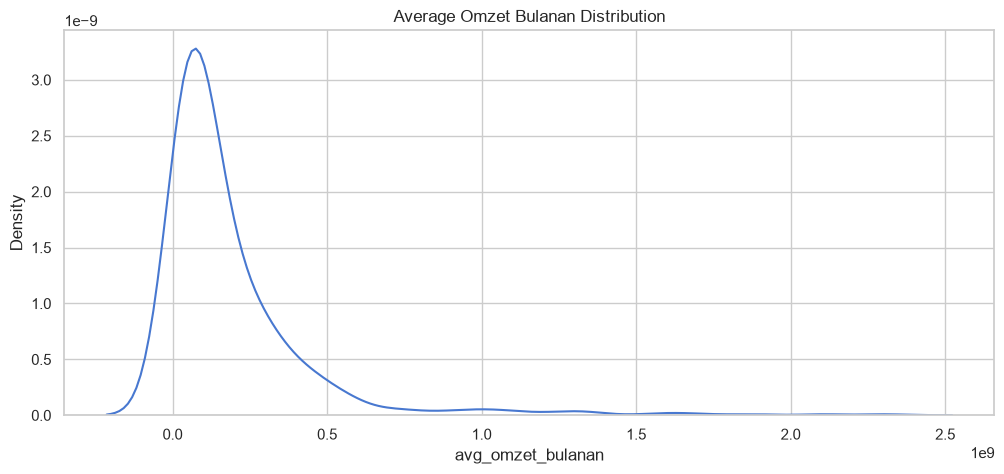

In [21]:
# check skewness avg_omzet_bulanan
print('Average omzet bulanan skewness:', merchants_clean['avg_omzet_bulanan'].skew())
sns.kdeplot(data=merchants_clean, x='avg_omzet_bulanan')
plt.title('Average Omzet Bulanan Distribution')
plt.show()

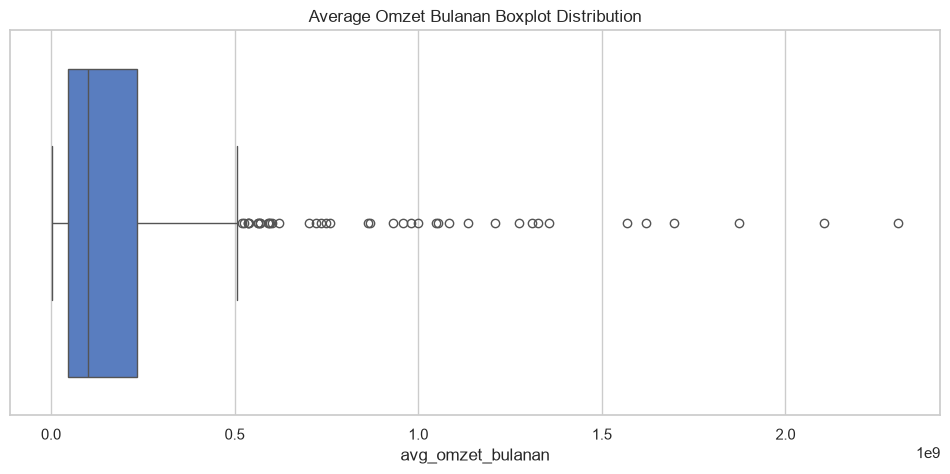

In [22]:
sns.boxplot(data=merchants_clean, x='avg_omzet_bulanan')
plt.title('Average Omzet Bulanan Boxplot Distribution')
plt.show()

Average omzet bulanan seems skewed-right distribution, yet the boxplot distribution also shows many data points outside of Q3 boundary. The most suitable way to impute missing values considering those condition is using median which robust to the outliers data.

In [23]:
# fill NULL avg_omzet_bulanan with median per category-type
merchants_clean['avg_omzet_bulanan'] = merchants_clean.groupby(['kategori', 'tipe'])['avg_omzet_bulanan'].transform(lambda x: x.fillna(x.median()))

# re-check missing values
merchants_clean.isna().sum()

merchant_id            0
nama                   0
kategori               0
sub_kategori           0
tipe                   0
kota                   0
kecamatan              0
is_nasabah_bni         0
produk_bni           221
tgl_registrasi       221
status               221
avg_omzet_bulanan      0
dtype: int64

In [24]:
produk_null = (merchants_clean['produk_bni'].isna())
tanggal_null = (merchants_clean['tgl_registrasi'].isna())
status_null = (merchants_clean['status'].isna())

merchants_null = merchants_clean[produk_null | tanggal_null | status_null]
print(f'Total merchants is_nasabah_bni == Tidak: {len(merchants_null['is_nasabah_bni'])}')
display(merchants_null.head())

Total merchants is_nasabah_bni == Tidak: 221


,merchant_id,nama,kategori,sub_kategori,tipe,kota,kecamatan,is_nasabah_bni,produk_bni,tgl_registrasi,status,avg_omzet_bulanan
435,M0649,Toko Sparepart Mas Bro,Automotive,dealer,retailer,Bogor,Dramaga,Tidak,NaN,NaN,NaN,53337964.0
436,M0701,mart surya,Grocery,toko_kelontong,retailer,Jakarta,Senayan,Tidak,NaN,NaN,NaN,67777253.0
437,M0597,Toko Sparepart Prima,Automotive,accessories,retailer,Bandung,Dago,Tidak,NaN,NaN,NaN,51501039.0
438,M0563,Digital Mas Bro,Electronics,gadget,retailer,Bandung,Cihampelas,Tidak,NaN,NaN,NaN,143811249.0
439,M0617,Motor Bersama,Automotive,sparepart,retailer,Depok,Margonda,Tidak,NaN,NaN,NaN,72453484.0


It's now all clear that remaining missing values on produk_bni, tgl_registrasi, status are expected because they have no partnership with BNI.

In [25]:
# summarize cleaning results
print(f"Total final merchants: {len(merchants_clean)}")
print(f"Total is_nasabah_bni == Ya: {(merchants_clean['is_nasabah_bni'] == 'Ya').sum()}")
print(f"Total is_nasabah_bni == Tidak: {(merchants_clean['is_nasabah_bni'] == 'Tidak').sum()}")
print(f"NULL nama: {merchants_clean['nama'].isna().sum()}")

Total final merchants: 656
Total is_nasabah_bni == Ya: 435
Total is_nasabah_bni == Tidak: 221
NULL nama: 0


## **3.2 Clean Transactions**

In [26]:
# remove duplicates of ref_number 
trx_clean = trx_raw.copy()

# remove duplicate ref_number
before_duplicates_removal = len(trx_clean)
trx_clean = trx_clean.drop_duplicates(subset='ref_number', keep='first')
print(f"Remove ref_number duplicates: {before_duplicates_removal} → {len(trx_clean)} (delete {before_duplicates_removal - len(trx_clean)})")

# remove failed & pending transactions
before_status_removal = len(trx_clean)
trx_clean = trx_clean[trx_clean['status'] == 'success']
print(f"Remove failed & pending status transactions: {before_status_removal} → {len(trx_clean)} (delete {before_status_removal - len(trx_clean)})")
 
# remove null amount
before = len(trx_clean)
trx_clean = trx_clean.dropna(subset=['amount'])
print(f"Delete null amount: {before} → {len(trx_clean)} (delete {before - len(trx_clean)})")
 
# remove negative amount (refunds) dan zero amount (test)
before = len(trx_clean)
trx_clean = trx_clean[trx_clean['amount'] > 0]
print(f"Delete refund and test amount (amount<=0): {before} → {len(trx_clean)} (delete {before - len(trx_clean)})")
 
# fill NULL channel with 'unknown'
trx_clean['channel'] = trx_clean['channel'].fillna('unknown')
 
# parse timestamp
trx_clean['timestamp_dt'] = pd.to_datetime(trx_clean['timestamp'])
trx_clean['hour'] = trx_clean['timestamp_dt'].dt.hour
trx_clean['day_of_week'] = trx_clean['timestamp_dt'].dt.day_name()
trx_clean['month'] = trx_clean['timestamp_dt'].dt.to_period('M')
 
# label transaction type
trx_clean['trx_type'] = np.where(trx_clean['source_id'].str.startswith('M'), 'M2M', 'C2M')
 
print(f"\nTransactions final: {len(trx_clean)}")
print(f"Merchant-to-Merchant (M2M): {(trx_clean['trx_type'] == 'M2M').sum()}")
print(f"Customer-to-Merchant (C2M): {(trx_clean['trx_type'] == 'C2M').sum()}")

Remove ref_number duplicates: 71400 → 69970 (delete 1430)
Remove failed & pending status transactions: 69970 → 64816 (delete 5154)
Delete null amount: 64816 → 64816 (delete 0)
Delete refund and test amount (amount<=0): 64816 → 64125 (delete 691)

Transactions final: 64125
Merchant-to-Merchant (M2M): 19054
Customer-to-Merchant (C2M): 45071


## **3.3 Clean Merchant Profiles**

In [27]:
# copy merchant profile df
profile_clean = merchant_profile.copy()
profile_clean.head()

,merchant_id,lama_beroperasi_tahun,jumlah_karyawan,rating_google,jumlah_outlet,has_website,has_social_media
0,M0001,20.0,37.0,4.8,5.0,Ya,Tidak
1,M0002,2.0,8.0,4.2,1.0,Ya,Ya
2,M0003,6.0,90.0,3.9,1.0,Ya,Tidak
3,M0004,17.0,26.0,4.7,1.0,Tidak,Tidak
4,M0005,15.0,6.0,3.7,1.0,Tidak,NaN


In [45]:
merchants['produk_bni'].value_counts()

produk_bni
EDC, QRIS    167
EDC          152
QRIS         143
Name: count, dtype: int64

In [28]:
# check skewness on profile_clean numeric data
for col in profile_clean.select_dtypes(include='number').columns:
    print(f'Skewness of {col} column: {profile_clean[col].skew()}')

Skewness of lama_beroperasi_tahun column: -0.09147875325627712
Skewness of jumlah_karyawan column: 0.9720587990060848
Skewness of rating_google column: 0.05218243716680965
Skewness of jumlah_outlet column: 1.9098502034659592


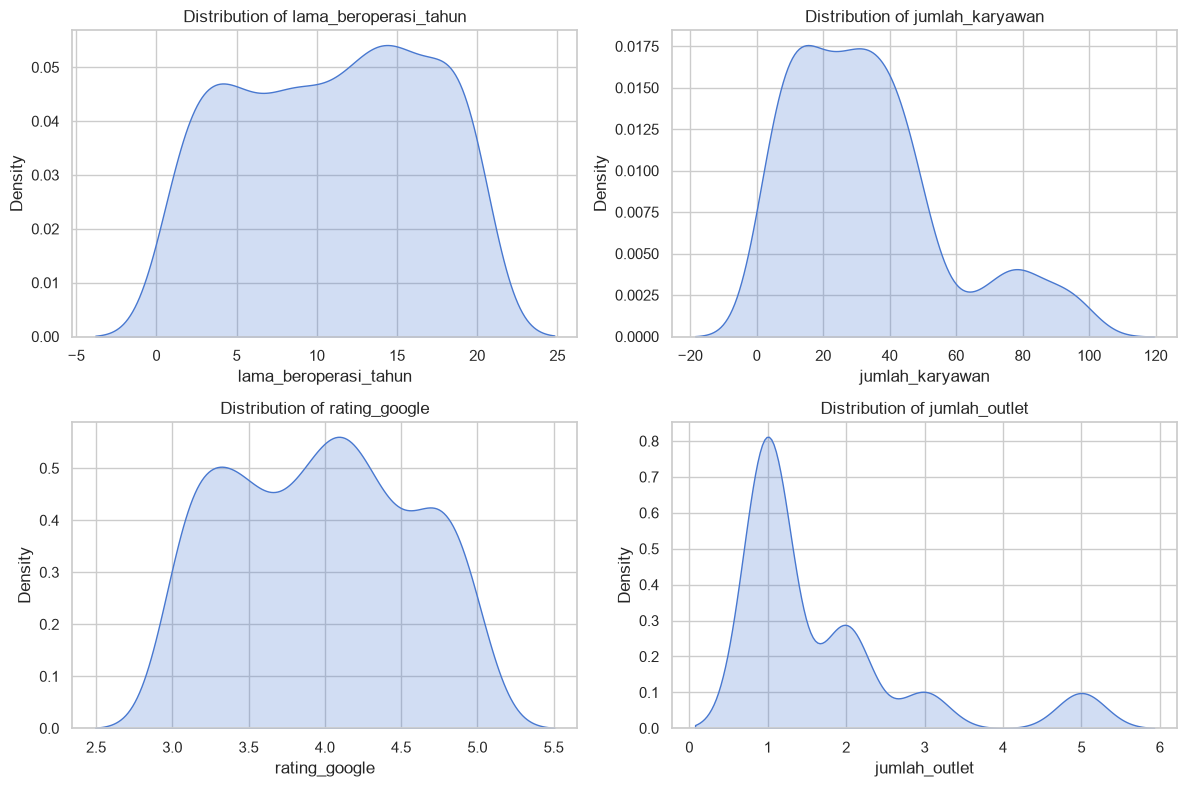

In [29]:
# make density subplots visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# convert array 2d into 1d for looping purposes
ax = ax.flatten()

for i, col in enumerate(profile_clean.select_dtypes(include='number').columns):  
    sns.kdeplot(
        data=profile_clean,
        x=col,
        fill=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

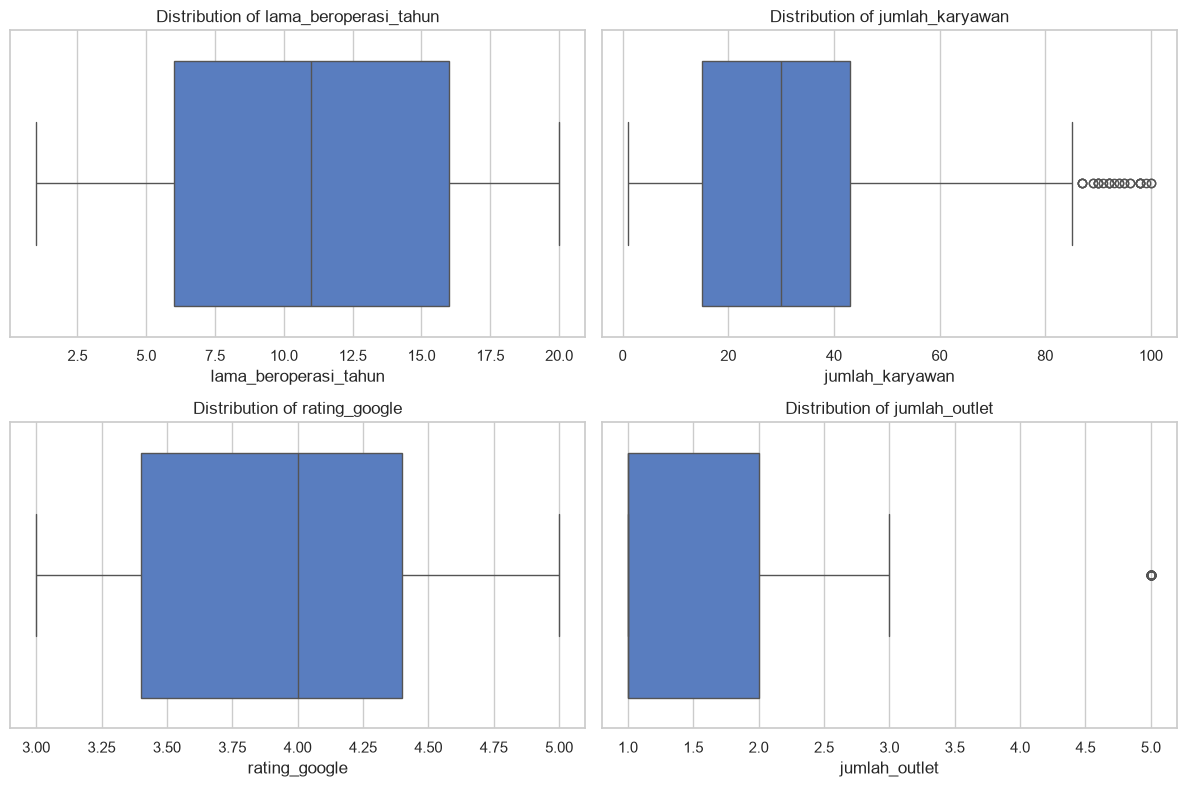

In [30]:
# make boxplot subplots visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# convert array 2d into 1d for looping purposes
ax = ax.flatten()

for i, col in enumerate(profile_clean.select_dtypes(include='number').columns):  
    sns.boxplot(
        data=profile_clean,
        x=col,
        fill=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [31]:
# fill missing value with median
for col in ['lama_beroperasi_tahun', 'jumlah_karyawan', 'jumlah_outlet']:
    median_val = profile_clean[col].median()
    null_count = profile_clean[col].isna().sum()
    profile_clean[col] = profile_clean[col].fillna(median_val)
    print(f"Fill {col} NULL ({null_count}) with median ({median_val})")

# let null value on rating_google, make new features has_rating containing binary values 
profile_clean['has_rating'] = profile_clean['rating_google'].notna().astype(int)
profile_clean['rating_google'] = profile_clean['rating_google'].fillna(0)  # 0 = no rating

# has_website dan has_social_media — encode ke binary
profile_clean['has_website'] = (profile_clean['has_website'] == 'Ya').astype(int)
profile_clean['has_social_media'] = (profile_clean['has_social_media'] == 'Ya').astype(int)

print(f"\nProfile clean shape: {profile_clean.shape}")
print(f"Missing values: {profile_clean.isnull().sum().sum()}")

Fill lama_beroperasi_tahun NULL (63) with median (11.0)
Fill jumlah_karyawan NULL (77) with median (30.0)
Fill jumlah_outlet NULL (37) with median (1.0)

Profile clean shape: (708, 8)
Missing values: 0


# **4. Exploratory Data Analysis**

## **4.1 Merchant Overview**

In [32]:
merchants_clean.groupby(['kategori', 'is_nasabah_bni']).size().unstack(fill_value=0)

is_nasabah_bni,Tidak,Ya
kategori,,
Automotive,32,71
Electronics,31,69
F&B,66,126
Fashion,39,91
Grocery,53,78


In [33]:
pd.crosstab(
    merchants_clean['kategori'],
    merchants_clean['is_nasabah_bni']
)

is_nasabah_bni,Tidak,Ya
kategori,,
Automotive,32,71
Electronics,31,69
F&B,66,126
Fashion,39,91
Grocery,53,78


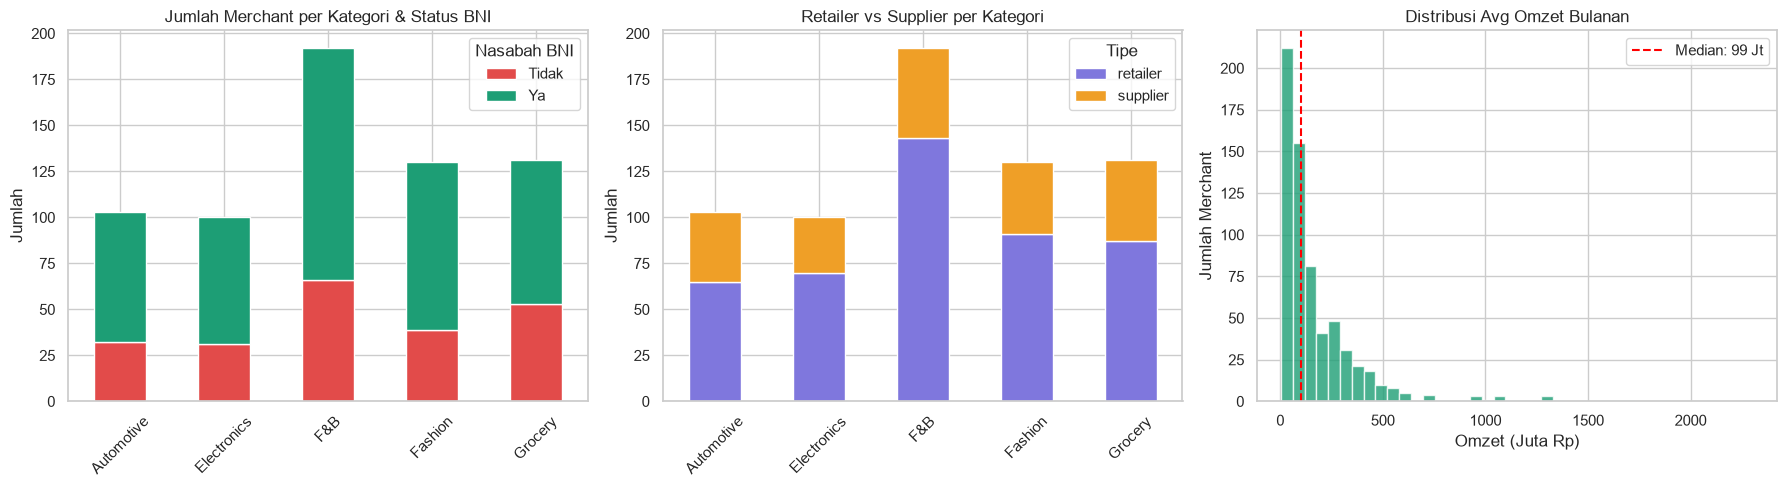

In [34]:
# set the subplots configuration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Merchant count per kategori, split by BNI status
ct = pd.crosstab(merchants_clean['kategori'], merchants_clean['is_nasabah_bni'])
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Jumlah Merchant per Kategori & Status BNI')
axes[0].set_xlabel('')
axes[0].set_ylabel('Jumlah')
axes[0].legend(title='Nasabah BNI')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Retailer vs Supplier per kategori
ct2 = pd.crosstab(merchants_clean['kategori'], merchants_clean['tipe'])
ct2.plot(kind='bar', stacked=True, ax=axes[1], color=['#7F77DD', '#EF9F27'])
axes[1].set_title('Retailer vs Supplier per Kategori')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah')
axes[1].legend(title='Tipe')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Average Omzet Bulanan Distribution
axes[2].hist(merchants_clean['avg_omzet_bulanan'].dropna() / 1e6, bins=40, color='#1D9E75', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribusi Avg Omzet Bulanan')
axes[2].set_xlabel('Omzet (Juta Rp)')
axes[2].set_ylabel('Jumlah Merchant')
axes[2].axvline(merchants_clean['avg_omzet_bulanan'].median() / 1e6, color='red', linestyle='--', label=f"Median: {merchants_clean['avg_omzet_bulanan'].median()/1e6:.0f} Jt")
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/01_merchants_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.2 Transactions Overview**

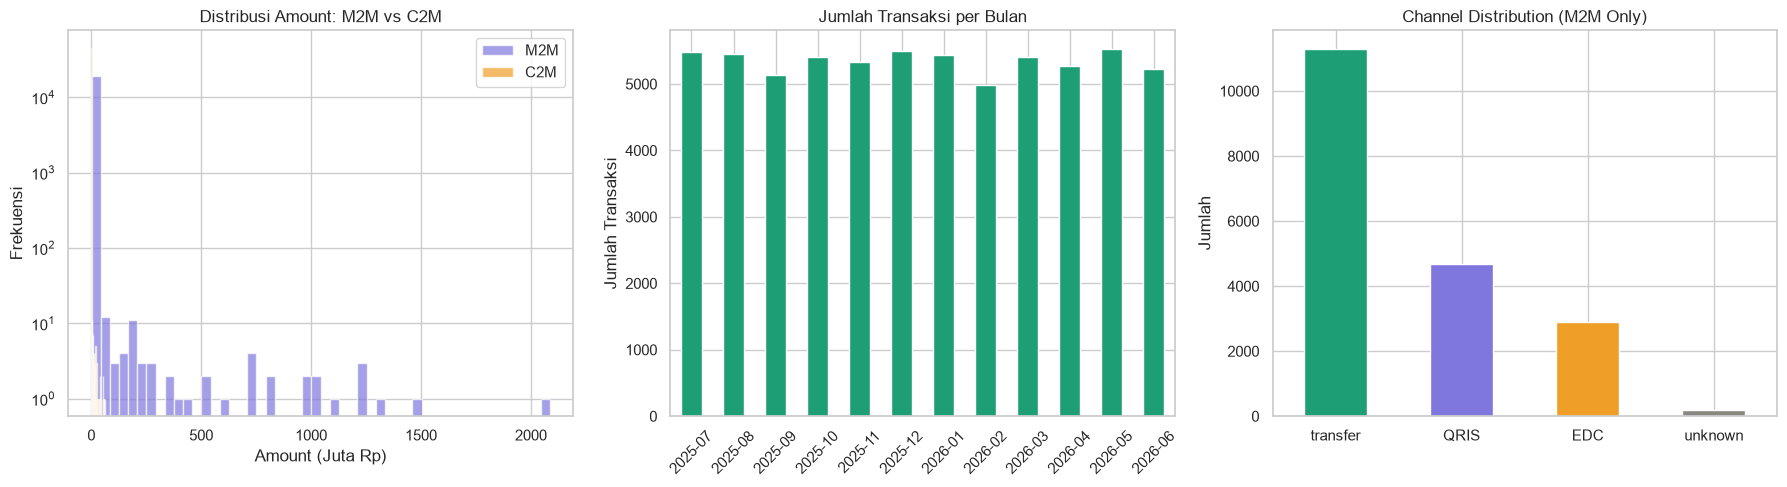

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution amount M2M vs C2M
m2m_amounts = trx_clean[trx_clean['trx_type'] == 'M2M']['amount'] / 1e6
c2m_amounts = trx_clean[trx_clean['trx_type'] == 'C2M']['amount'] / 1e6

axes[0].hist(m2m_amounts, bins=50, alpha=0.7, label='M2M', color='#7F77DD')
axes[0].hist(c2m_amounts, bins=50, alpha=0.7, label='C2M', color='#EF9F27')
axes[0].set_title('Distribusi Amount: M2M vs C2M')
axes[0].set_xlabel('Amount (Juta Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].set_yscale('log')

# Plot 2: Transaction count per month
monthly = trx_clean.groupby('month').size()
monthly.plot(kind='bar', ax=axes[1], color='#1D9E75', edgecolor='white')
axes[1].set_title('Jumlah Transaksi per Bulan')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Channel distribution for M2M
m2m_channels = trx_clean[trx_clean['trx_type'] == 'M2M']['channel'].value_counts()
m2m_channels.plot(kind='bar', ax=axes[2], color=['#1D9E75', '#7F77DD', '#EF9F27', '#888780'])
axes[2].set_title('Channel Distribution (M2M Only)')
axes[2].set_xlabel('')
axes[2].set_ylabel('Jumlah')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/02_transactions_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.3 Transaction Time Heatmap**

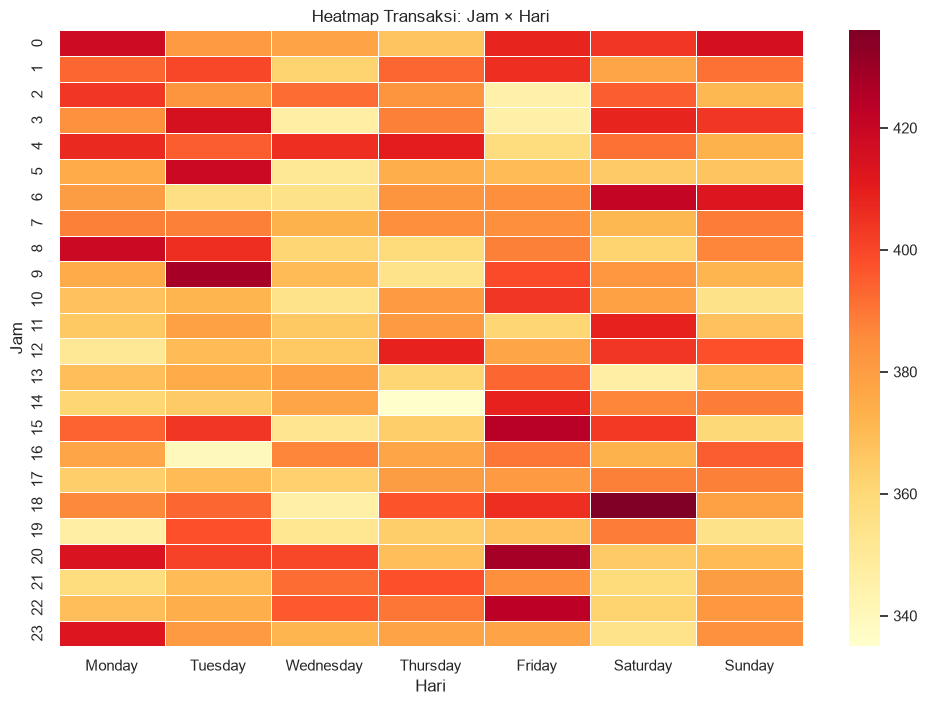

In [36]:
hour_day = trx_clean.pivot_table(index='hour', columns='day_of_week', values='trx_id', aggfunc='count',
                                  fill_value=0)
# Reorder days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_day = hour_day.reindex(columns=[d for d in day_order if d in hour_day.columns])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(hour_day, cmap='YlOrRd', linewidths=0.5, ax=ax, fmt='d', annot=False)
ax.set_title('Heatmap Transaksi: Jam × Hari')
ax.set_xlabel('Hari')
ax.set_ylabel('Jam')
plt.savefig(f'{PROJECT_ROOT}/plots/03_heatmap_hour_day.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.4 Features Correlation Check**

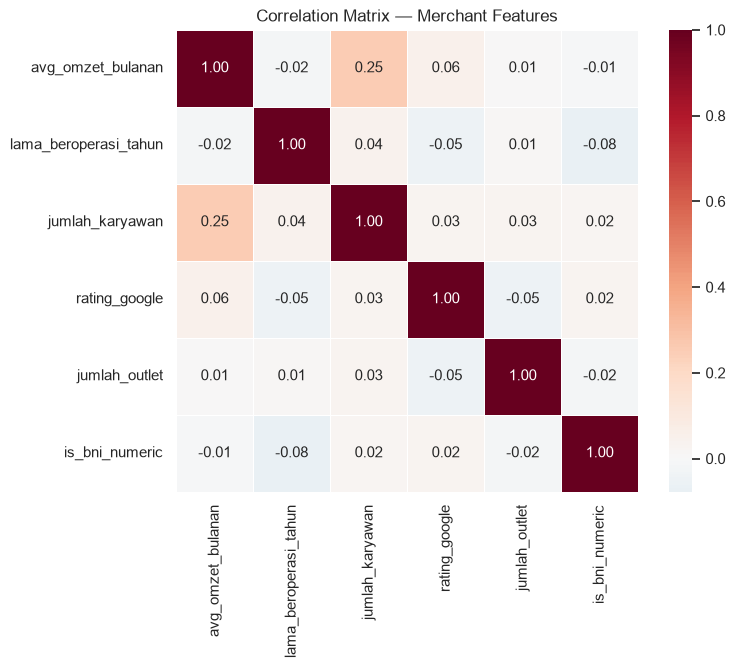

In [37]:
# merge merchants_clean and profile_clean
merchants_enriched = merchants_clean.merge(profile_clean, on='merchant_id', how='left')

# encode is_nasabah_bni to numeric for corrleation analysis
merchants_enriched['is_bni_numeric'] = (merchants_enriched['is_nasabah_bni'] == 'Ya').astype(int)

# Correlation matrix — fitur numerik
numeric_cols = ['avg_omzet_bulanan', 'lama_beroperasi_tahun', 'jumlah_karyawan', 
                'rating_google', 'jumlah_outlet', 'is_bni_numeric']
corr_matrix = merchants_enriched[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Merchant Features')
plt.savefig(f'{PROJECT_ROOT}/plots/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.5 Data Separation Check**

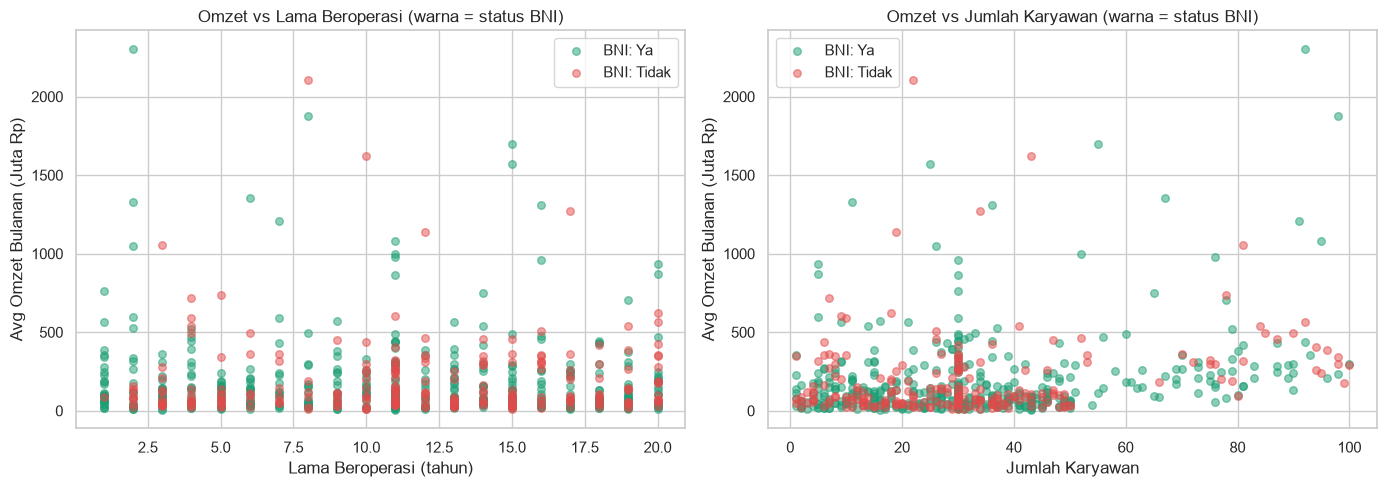

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Ya': '#1D9E75', 'Tidak': '#E24B4A'}

for status, color in colors.items():
    mask = merchants_enriched['is_nasabah_bni'] == status
    axes[0].scatter(
        merchants_enriched.loc[mask, 'lama_beroperasi_tahun'],
        merchants_enriched.loc[mask, 'avg_omzet_bulanan'] / 1e6,
        c=color, alpha=0.5, label=f'BNI: {status}', s=30
    )

axes[0].set_xlabel('Lama Beroperasi (tahun)')
axes[0].set_ylabel('Avg Omzet Bulanan (Juta Rp)')
axes[0].set_title('Omzet vs Lama Beroperasi (warna = status BNI)')
axes[0].legend()

# Scatter: Omzet vs Jumlah Karyawan
for status, color in colors.items():
    mask = merchants_enriched['is_nasabah_bni'] == status
    axes[1].scatter(
        merchants_enriched.loc[mask, 'jumlah_karyawan'],
        merchants_enriched.loc[mask, 'avg_omzet_bulanan'] / 1e6,
        c=color, alpha=0.5, label=f'BNI: {status}', s=30
    )

axes[1].set_xlabel('Jumlah Karyawan')
axes[1].set_ylabel('Avg Omzet Bulanan (Juta Rp)')
axes[1].set_title('Omzet vs Jumlah Karyawan (warna = status BNI)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/05_scatter_nonlinearity.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. C2M Transaction Filtering**

Graph analytics sekarang dibangun dari Customer Affinity (C2M)


In [43]:
# Filter only C2M transactions
trx_c2m = trx_clean[trx_clean['trx_type'] == 'C2M'].copy()
print(f"Clean transactions total data: {len(trx_clean)}")
print(f"C2M transactions: {len(trx_c2m)}")
print(f"M2M transactions (excluded from graph): {len(trx_clean) - len(trx_c2m)}")

# make sure ONLY target_id appears in merchants_clean (because source_id is a customer)
valid_merchant_ids = set(merchants_clean['merchant_id'].tolist())
trx_c2m = trx_c2m[
    trx_c2m['target_id'].isin(valid_merchant_ids)
]
print(f"C2M after merchant_id validation process: {len(trx_c2m)}")


Clean transactions total data: 64125
C2M transactions: 45071
M2M transactions (excluded from graph): 19054
C2M after merchant_id validation process: 42005


# **6. Save Processed Data**

In [ ]:
merchants_clean.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_clean.csv', index=False)
trx_clean.to_csv(f'{PROJECT_ROOT}/data/processed/transactions_clean.csv', index=False)
trx_c2m.to_csv(f'{PROJECT_ROOT}/data/processed/transactions_c2m.csv', index=False)
profile_clean.to_csv(f'{PROJECT_ROOT}/data/processed/profiles_clean.csv', index=False)
merchants_enriched.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_enriched.csv', index=False)

print("Saving processed data. . .")
print(f"merchants_clean.csv:      {len(merchants_clean)} rows")
print(f"transactions_clean.csv:   {len(trx_clean)} rows")
print(f"transactions_m2m.csv:     {len(trx_m2m)} rows")
print(f"profiles_clean.csv:       {len(profile_clean)} rows")
print(f"merchants_enriched.csv:   {len(merchants_enriched)} rows")

Saving processed data. . .
merchants_clean.csv:      656 rows
transactions_clean.csv:   64125 rows
transactions_m2m.csv:     16660 rows
profiles_clean.csv:       708 rows
merchants_enriched.csv:   656 rows


In [41]:
# Verifikasi output notebook 01
print("=== VERIFIKASI OUTPUT NOTEBOOK 01 ===")
print(f"merchants_clean    : {len(merchants_clean)} merchant")
print(f"  BNI              : {(merchants_clean['is_nasabah_bni']=='Ya').sum()}")
print(f"  Bukan BNI        : {(merchants_clean['is_nasabah_bni']=='Tidak').sum()}")
print(f"  Produk QRIS only : {(merchants_clean['produk_bni']=='QRIS').sum()}")
print(f"  Produk EDC only  : {(merchants_clean['produk_bni']=='EDC').sum()}")
print(f"  Produk EDC+QRIS  : {(merchants_clean['produk_bni']=='EDC, QRIS').sum()}")
print(f"  Produk NULL      : {merchants_clean['produk_bni'].isna().sum()}")
print(f"transactions_clean : {len(trx_clean)} transaksi")
print(f"  C2M              : {(trx_clean['trx_type']=='C2M').sum()}")
print(f"  M2M              : {(trx_clean['trx_type']=='M2M').sum()}")
print(f"\n✓ Siap untuk notebook 02")

=== VERIFIKASI OUTPUT NOTEBOOK 01 ===
merchants_clean    : 656 merchant
  BNI              : 435
  Bukan BNI        : 221
  Produk QRIS only : 139
  Produk EDC only  : 145
  Produk EDC+QRIS  : 151
  Produk NULL      : 221
transactions_clean : 64125 transaksi
  C2M              : 45071
  M2M              : 19054

✓ Siap untuk notebook 02
